# Homework 7: Convolutional Neural Networks
**Name:** Nicholas Starace  
**Student ID:** 4556822  
**D Value:** 22  

## Question 1 From HW6 to CNNs - Conceptual Foundations

### Part A: Connecting to HW6

**Written Response:**  
HW6 Best Accuracy: 56.9%  
A fully connected network struggles with raw pixel features because the vechile photos aren't standardized. For example, properties of the photo that have no influence over the output (ex. position of a plane doesn't make it a car) will be detected as signficiant differences to capture in training. Therefore, shfting or rotating a photo will cause the NN to train on what it thinks is a complely new image.  

### Part B: How CNNs Solve the Problem - A Detailed Illustration

**Written Response:**  
1. Weight sharing reduces the number of learnable parameters compared to a fully connected layer by connecting the neurons to regions of the image. Taking a 32 x 32 dimension image with a total of 1024 pixels, a 3x3 filter can be applied to the image resulting in one shared weight instead of nine individual ones. Applying to the entire photo, the number of weights required is about 114 instead of 1024, significantly reducting the dimension of the problem.  
2. Hierarchial feature learning is more powerful than a single layer of filters because it can extract a wide variety of complexity in the pattern space. With multiple layers, the first and second can detect edges, gradients, corners, and textures. The third layer can sometimes capture entire structures such as wheels or wings. Adding more layers effectively places more pieces of the puzzle. An example of layer capabilties is detecting a car where the first layer might outline an entire car including the body and wheels. The second layer may refine this outline by finding textures and seaparating the body from the wheels and tires.  
3. Max-pooling may help our vehicle classifier because it is more tolerant to an objects position varying from photo to photo. This translation invariance enables an object such as a wheel to be in a different part of the photo and still be detected. Pooling absorbs translation, movement around the expected position. 

## Question 2: Building and Training a CNN

### Part A: Data Preparation

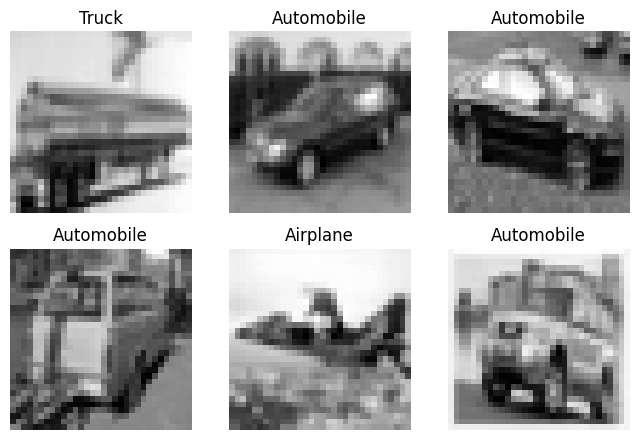

In [38]:
import os
import cv2
import scipy.io
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

# Random Seed D + 1
D = 22

# Load Dataset
data = scipy.io.loadmat('input/HW6_Data2_full.mat')
X = np.array(data['X'])
y = np.array(data['y_labels'])
y = y.ravel()

# Split 13000 train, 2000 test
np.random.seed(D + 1)
start = 0
mid = 13000
end = 15000
randArr = np.random.permutation(X.shape[0])
X_train = X[randArr[start:mid], :]
X_test = X[randArr[mid:end], :]
y_train = y[randArr[start:mid]]
y_test = y[randArr[mid:end]]

# Reshape to Photo
X_train_P = X_train.reshape(-1, 32, 32, 1)
X_test_P = X_test.reshape(-1, 32, 32, 1)

# Find global max from training data
maxP = tf.reduce_max(X_train_P)

# Normalize
X_train_P = X_train_P / maxP
X_test_P  = X_test_P / maxP

# One-Hot Vector Encoding
y_train_oh = tf.keras.utils.to_categorical(y_train - 1, num_classes=3)
y_test_oh = tf.keras.utils.to_categorical(y_test - 1, num_classes=3)

# Decode Class Names
labels = np.array(["Airplane", "Automobile", "Truck"])

# Randomly Select Images
np.random.seed(D + 1)
start = 0
mid = 4 + (D % 5)
end = X.shape[0]
randArr = np.random.permutation(X.shape[0])
X_show = X[randArr[start:mid], :]
y_show = y[randArr[start:mid]]

# Display Random Images in Grid
plt.figure(figsize=(8, 8))
for i in range(mid):
    img = X_show[i, :].reshape(32, 32, order='F')
    classlabel = labels[y_show[i] - 1]  # -1 since indexed from 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{classlabel}")
    plt.axis("off")


**Written Response:**  
Dimension of Training (Reshaped) = 1300 x 32 x 32 x 1  
Dimension of Testing (Reshaped) = 2000 x 32 x 32 x 1  
Normalization Factor = 1 (already normalized?)  
Number of Images Displayed = 6

### Part B: CNN Architecture Design

In [ ]:
# Design CNN
model = models.Sequential([
    layers.Conv2D(filters=8+(D%8), kernel_size=(3,3), activation='relu', padding='same'),       # Layer 1: Conv2D
    layers.MaxPooling2D(pool_size=(2,2)),                                                       # Layer 2: MaxPooling
    layers.Conv2D(filters=16+(D%16), kernel_size=(3,3), activation='relu', padding='same'),     # Layer 3: Conv2D
    layers.MaxPooling2D(pool_size=(2,2)),                                                       # Layer 4: MaxPooling
    layers.Flatten(),                                                                           # Layer 5: Flatten
    layers.Dense(32+(D%32), activation='relu'),                                                 # Layer 6: Dense
    layers.Dense(3, activation='softmax')                                                       # Layer 7: Output Dense
])

model.build((None, 32, 32, 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 14)     │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 14)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 22)     │         2,794 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 22)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 54)             │        76,086 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,185 (309.32 KB)

 Trainable params: 79,185 (309.32 KB)

 Non-trainable params: 0 (0.00 B)

**Written Response:**  
D = 22  
Layer 1: 8 + (22 % 8) --> 22 / 8 = 2R6 --> 8 + (6) = 14  
Layer 3: 16 + (22 % 16) --> 22 / 16 = 1R6 --> 16 + (6) = 22  
Layer 6: 32 + (22 % 32) --> 22 / 32 = 0R22 --> 32 + (22) = 54  
  
Total Number of Trainable Params = 79,185  
  
Compared to HW6 where the NN had over 100,000 parameters, the CNN has significantly less parameters to find. While smaller, the CNN will most likely perform better since it implements weight sharing. This weight sharing will make the model more tolerant to translation from photo to photo. 

### Part C: Training

Epoch 1/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6131 - loss: 0.8373 - val_accuracy: 0.6638 - val_loss: 0.7579
Epoch 2/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6840 - loss: 0.7030 - val_accuracy: 0.6362 - val_loss: 0.7417
Epoch 3/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7344 - loss: 0.6276 - val_accuracy: 0.7646 - val_loss: 0.6429
Epoch 4/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7629 - loss: 0.5771 - val_accuracy: 0.7754 - val_loss: 0.5621
Epoch 5/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7904 - loss: 0.5235 - val_accuracy: 0.7723 - val_loss: 0.5261
Epoch 6/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8100 - loss: 0.4856 - val_accuracy: 0.8162 - val_loss: 0.4755
Epoch 7/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8285 - loss: 0.4482 - val_accuracy: 0.8308 - val_loss: 0.4492
Epoch 8/14
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8376 - loss: 0.4233 - val_accuracy: 0.

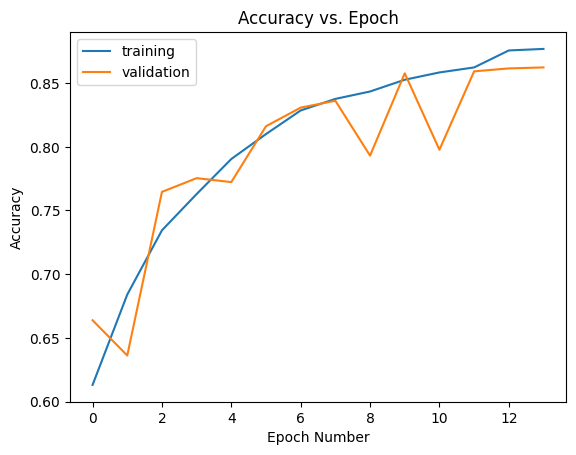

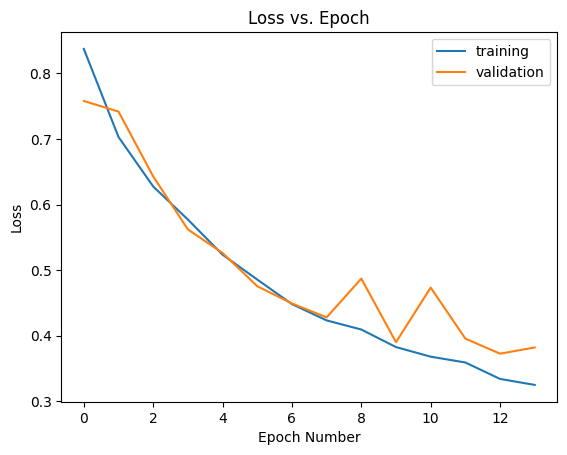

In [3]:
# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_P, y_train_oh, batch_size=64+(D%64), epochs=10+(D%6), validation_split=0.1)

# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.legend(['training', 'validation'])
plt.title('Accuracy vs. Epoch')
plt.show()

# Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.legend(['training', 'validation'])
plt.title('Loss vs. Epoch')
plt.show()

**Written Response:**  
Batch Size = 64 + (22 % 64) -> 22 / 64 = 0R22 -> 64 + (22) = 86  
Epochs = 10 + (22 % 6) -> 22 / 6 =  3R4 -> 10 + (4) = 14  
  
The model is generally well-fitted. The loss curves show exponential decreases across epochs. The model may benefit from additional epochs since the loss curves don't appear to fully reach an asymptote.  
  
Training Accuracy: 87.7%  
Validation Accuracy: 86.2%


### Part D: Evaluation and Comparison with HW6

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8295 - loss: 0.4200
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Confusion Matrix:
[[562  49  29]
 [ 25 626  34]
 [ 47 157 471]]


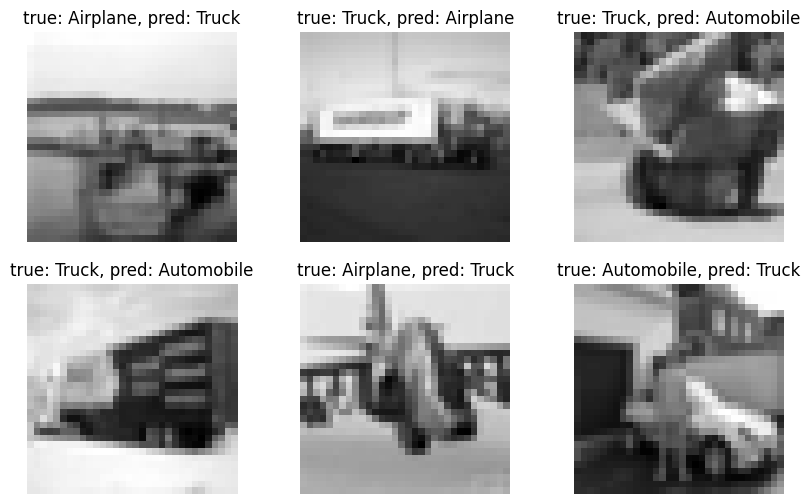

In [30]:
# Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test_P, y_test_oh)

# Find Predictions
y_pred_probs = model.predict(X_test_P)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)

# Confusoin Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Find Misclassified Images
missIdx = np.where(y_pred != y_true)[0]

# Plot 6 Incorrect Images
plt.figure(figsize=(10,6))
for i in range(6):
    idx = missIdx[i]
    
    plt.subplot(2, 3, i+1)
    plt.imshow(X_test[idx, :].reshape(32, 32, 1, order='F'), cmap='gray')
    
    labelT = labels[y_true[idx]]  # -1 since indexed from 0
    labelP = labels[y_pred[idx]]

    plt.title(f"true: {labelT}, pred: {labelP}")
    plt.axis('off')

plt.show()


In [35]:
# Summarize Results
print("Method\t\tDataset\t\tTest Accuracy [%]\t# Trainable Parameters")
print("NN\t\tVehicles\t56.9\t\t\t136000")
print("CNN\t\tVehicles\t87.7\t\t\t79185")

Method		Dataset		Test Accuracy [%]	# Trainable Parameters
NN		Vehicles	56.9			136000
CNN		Vehicles	87.7			79185


**Written Response:**  
Accuracy Gap: Accuracy improved by 30.8% compared to a fully connected NN. The improvement is expected since the use of weight sharing made the model more robust against translation between images. Compared to the NN which only looked at pixel features, the CNN was able to extract and analyze patterns in the image regardless of location.  
Confusion Matrix Analysis: The automobiles and trucks were most often confused. More specifically, many automobile images were predicted as trucks. This confusion is understandable as trucks and cars are very similar only differing slightly in shape and in size. In a small 32 x 32 grayscale image, it can be sometimes impossible even as a human to detect the difference.  
Misclassified Images: As explained by the confusion matrix, most of the 6 misclassified 6 images consist of trucks and automobiles. Certain images such as the misclassifed airplane closely resemble other classes by being physically large. Other images were misclassified most likely due to busy backgrounds. Remaining misclassified images have such poor detail that as a human it's nearly impossible to detect vehicle type.  

## Question 3: Sliding-Window Object Detection

### Part A: Training the Detector 

50
50


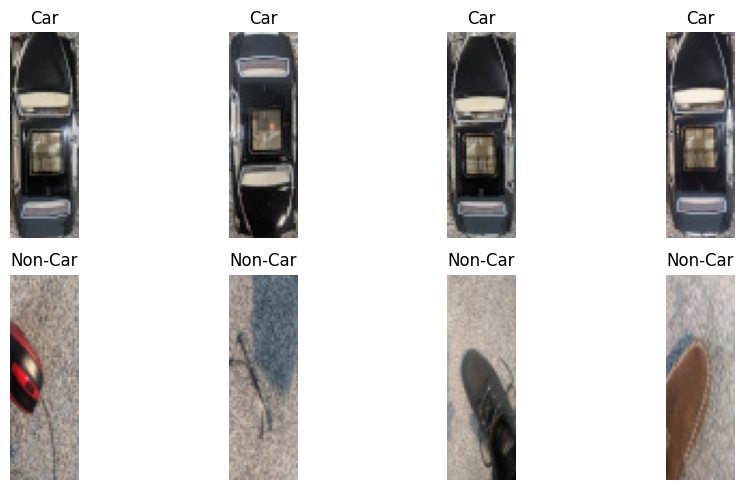

In [53]:
# Import Images and Parse Labels
folder = './input/p2/train_imgs/'
filenames = sorted(os.listdir(folder))
imgs, labels = [], []
for f in filenames:
    img = cv2.imread(os.path.join(folder, f))
    imgs.append(img)
    labels.append(int(f[0])) # First char is label
imgs_train = np.array(imgs) # shape: (100, 96, 32, 3)
y_train = np.array(labels) # shape: (100,)
X = imgs_train

# Class Distribution
numCar = (y_train == 1).sum()
numNonCar = (y_train == 0).sum()
print(numCar)
print(numNonCar)

# Separate indices by class
car_idx = np.where(y_train == 1)[0]
non_idx = np.where(y_train == 0)[0]

# Shuffle and pick 4 from each
np.random.seed(D)
car_sel = np.random.choice(car_idx, 4, replace=False)
non_sel = np.random.choice(non_idx, 4, replace=False)

# Combine selections
sel_idx = np.concatenate((car_sel, non_sel))

# Extract images and labels
X_show = X[sel_idx]
y_show = y_train[sel_idx]

# Display
plt.figure(figsize=(10, 5))

for i in range(8):
    img = X_show[i]

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{'Car' if y_show[i] == 1 else 'Non-Car'}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 96, 32, 14)     │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 16, 14)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 54)             │       580,662 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581,164 (2.22 MB)

 Trainable params: 581,164 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.5556 - loss: 0.7376 - val_accuracy: 1.0000 - val_loss: 0.3838
Epoch 2/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9667 - loss: 0.4486 - val_accuracy: 1.0000 - val_loss: 0.2182
Epoch 3/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9667 - loss: 0.3413 - val_accuracy: 0.0000e+00 - val_loss: 1.1928
Epoch 4/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7778 - loss: 0.3444 - val_accuracy: 0.0000e+00 - val_loss: 1.1921
Epoch 5/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7778 - loss: 0.3057 - val_accuracy: 1.0000 - val_loss: 0.3734
Epoch 6/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0972 - val_accuracy: 1.0000 - val_loss: 0.0970
Epoch 7/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0622 - val_accuracy: 1.0000 - val_loss: 0.0504
Epoch 8/17
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.0816 - val_accuracy: 1.0000 - val_los

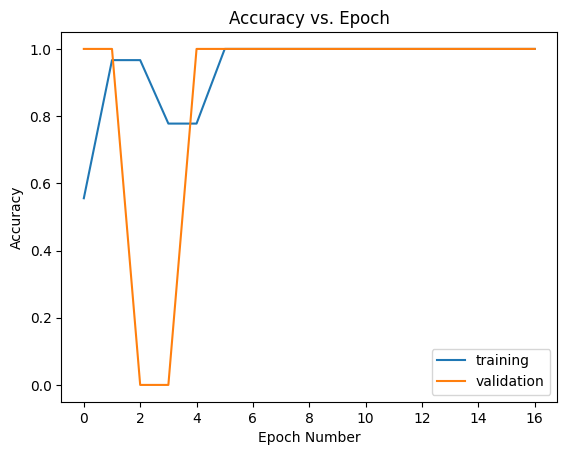

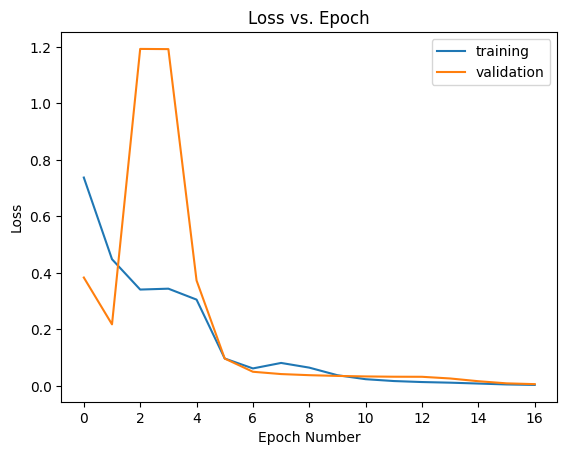

In [ ]:
NumLayers = 2 + (D % 2) # = 2

# Normalize
maxP = tf.reduce_max(imgs_train)
imgs_train = imgs_train / maxP

# Design CNN
model = models.Sequential([
    layers.Input(shape=(96, 32, 3)),                                                            # ADDED 
    layers.Conv2D(filters=8+(D%8), kernel_size=(3,3), activation='relu', padding='same'),       # Layer 1: Conv2D
    layers.MaxPooling2D(pool_size=(2,2)),                                                       # Layer 2: MaxPooling
    layers.Flatten(),                                                                           # Layer 5: Flatten
    layers.Dense(32+(D%32), activation='relu'),                                                 # Layer 6: Dense
    layers.Dense(2, activation='softmax')                                                       # Layer 7: Output Dense
])

model.build((None, 96, 32, 3))
model.summary()

# Compile Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(imgs_train, y_train, batch_size=64+(D%64), epochs=15+(D%10), validation_split=0.1)

# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.legend(['training', 'validation'])
plt.title('Accuracy vs. Epoch')
plt.show()

# Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.legend(['training', 'validation'])
plt.title('Loss vs. Epoch')
plt.show()

**Written Response:**  
Training accuracy reached 100% at epoch 6/17.  
The model was kept identical to the architecture used in the previous question with two modifications. Layers 3 and 4 were removed because of the obvious differences in the feature space. By visualizing the 8 training samples, it was obvious which images were cars and which weren't cars. Therefore, only one stage of convolution and pooling were used to ensure that there wasn't too much smoothing that would cause both cars and non-cars to appear identical (preventing underfitting).

### Part B: Implementing the Sliding Window

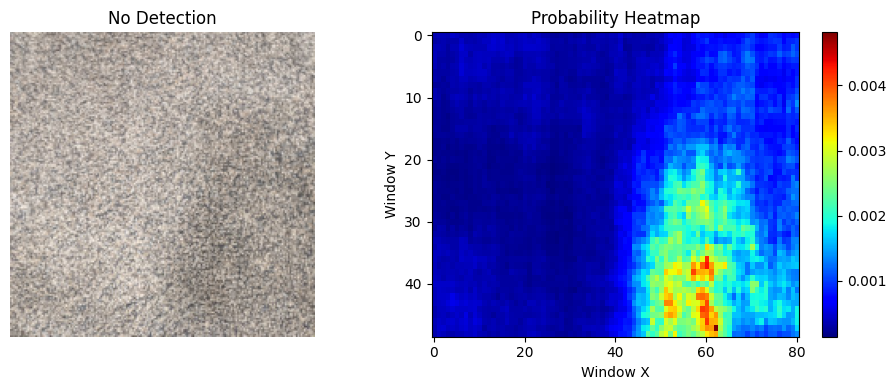

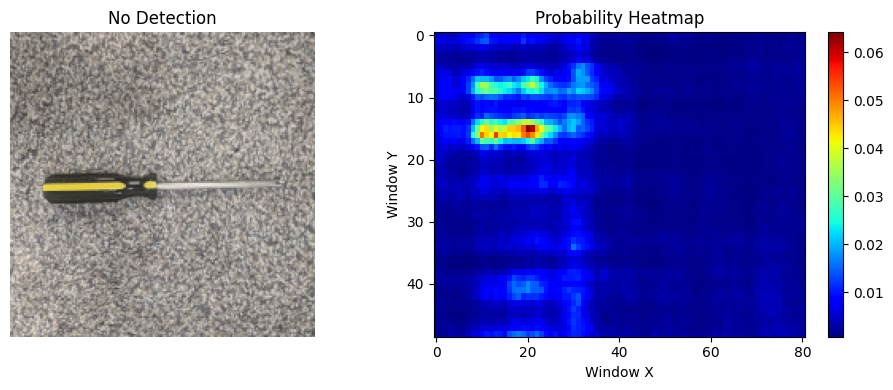

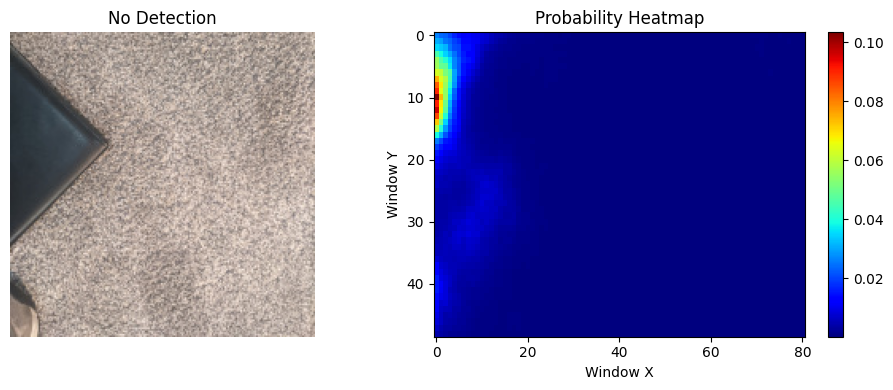

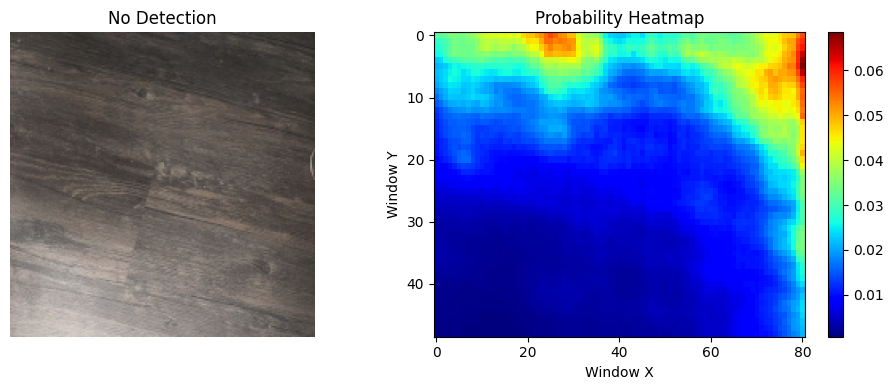

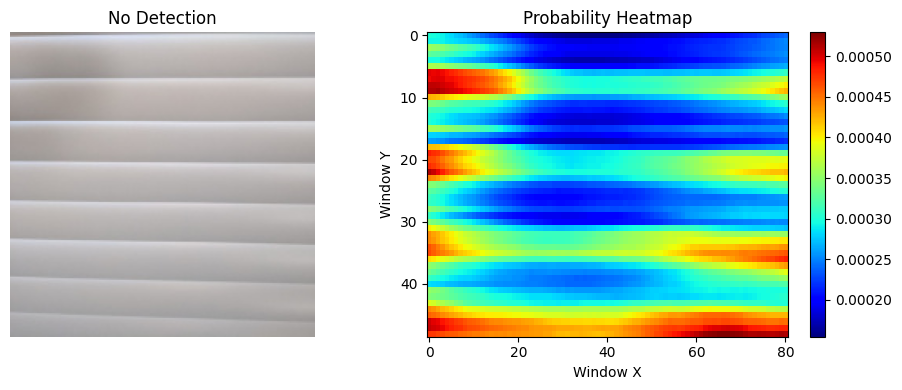

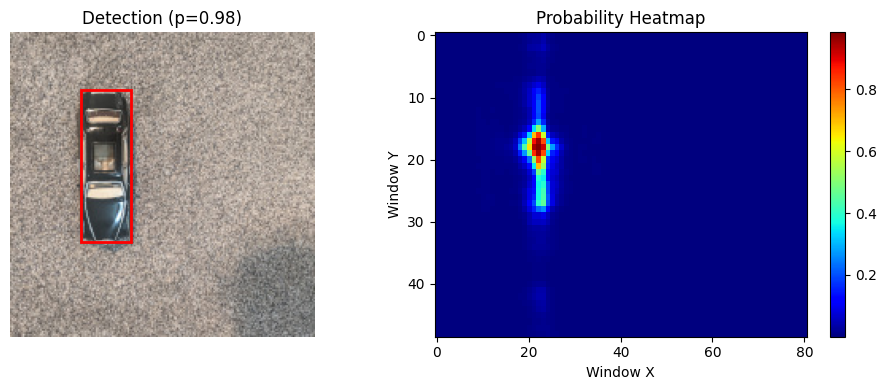

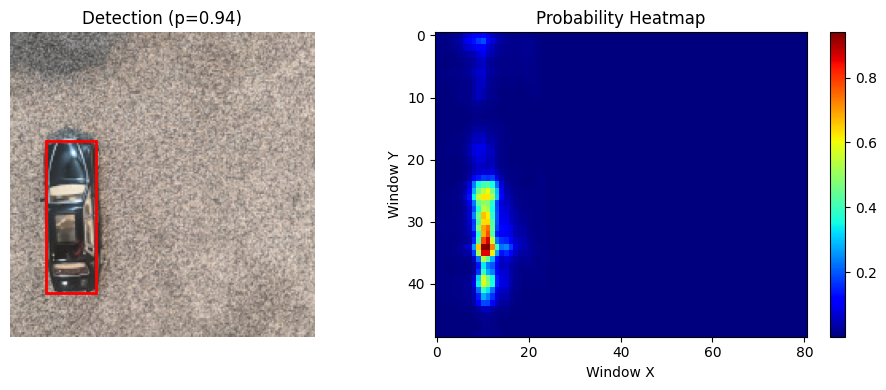

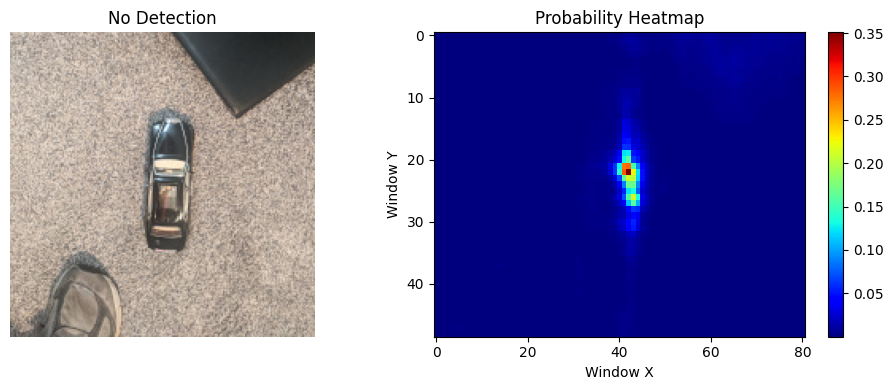

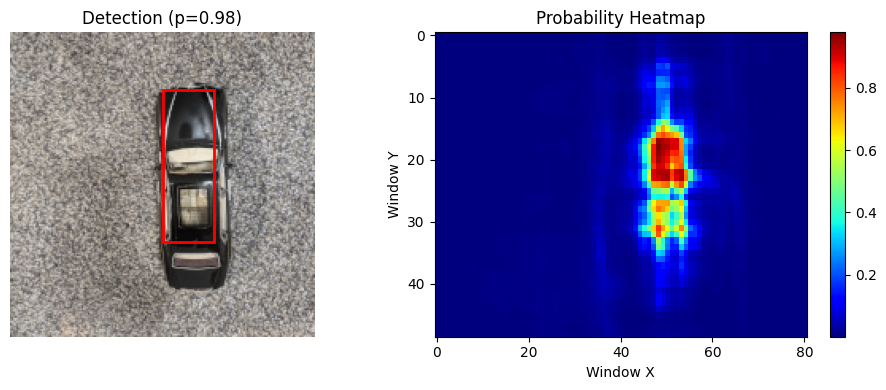

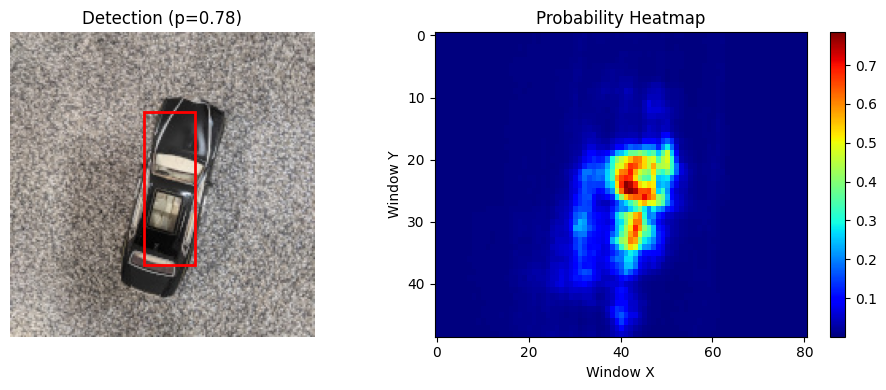

In [ ]:
# Parameters
stride = 1 + (D % 3)
threshold = 0.5 + (D % 20) / 100

test_folder = './input/p2/test_imgs/'
test_files = sorted(os.listdir(test_folder))

for f in test_files:
    # Load image and Normalize
    img = cv2.imread(os.path.join(test_folder, f))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img.astype('float32') / 255.0

    H, W, _ = img.shape

    # Compute number of valid positions
    out_h = (H - 96) // stride + 1
    out_w = (W - 32) // stride + 1

    heatmap = np.zeros((out_h, out_w))

    # Sliding window
    for i in range(out_h):
        for j in range(out_w):
            y = i * stride
            x = j * stride

            # Kernel
            patch = img_norm[y:y+96, x:x+32, :]

            # Add batch dimension
            patch = np.expand_dims(patch, axis=0)

            # Predict probability
            probs = model.predict(patch, verbose=0)

            # Assuming class 1 = "car"
            heatmap[i, j] = probs[0][1]

    # Detection
    max_prob = np.max(heatmap)

    plt.figure(figsize=(10, 4))

    # Display Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.axis("off")

    if max_prob > threshold:
        # Get location of max probability
        idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        i_max, j_max = idx

        y = i_max * stride
        x = j_max * stride

        # Draw rectangle
        rect = plt.Rectangle((x, y), 32, 96, edgecolor='red', facecolor='none', linewidth=2)
        plt.gca().add_patch(rect)

        plt.title(f"Detection (p={max_prob:.2f})")
    else:
        plt.title("No Detection")

    # Display Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(heatmap, cmap='jet', aspect='auto')
    plt.colorbar()
    plt.title("Probability Heatmap")
    plt.xlabel("Window X")
    plt.ylabel("Window Y")
    plt.show()

**Written Response:**  
Stride Value: 1 + (D % 3) -> 22 / 3 = 7R1 -> 1 + (1) = 2  
Detection Threshold: 0.5 + (D % 20) / 100 -> 22 / 20 = 1R2 -> 0.5 + (0.02) = 0.52

### Part C: Detection Analysis

**Written Response:**  
Results Summary:  
| Image | Present | Correct Detection | Max Probability | 
|-------|---------|-------------------|-----------------|
| 1     |    no   |     yes           |      0.005      |
| 2     |    no   |     yes           |      0.06       |
| 3     |    no   |     yes           |      0.10       |
| 4     |    no   |     yes           |      0.07       |
| 5     |    no   |     yes           |      0.00055    |
| 6     |    yes  |     yes           |      0.98       |
| 7     |    yes  |     yes           |      0.94       |
| 8     |    yes  |     no            |      0.35       |
| 9     |    yes  |     yes           |      0.98       |
| 10    |    yes  |     yes           |      0.78       |  
  
False Positives and False Negatives: The system produced one false negative in image 8. By analyzing the heatmap, the system detected a max probability of 0.35 around the center of the car but did not meet the threshold to labeled as a car. Additionally, the heatmap was localized to nearly a single point in the image, voiding it from detection.  
  
Limitations of Sliding Window: If the car appeared rotated, the model may struggle to classify these cars because it is only trained on 96 x 32 size images. Additionally, if the cars were rotated, the edges learned in training would be different from a rotated car. To handle differences in scale, the model might benefit from being trained on an image set that has images of cars that have these variations in rotation or scale.  
  
Connection to Modern Models: Other methods are more efficient than brute force sliding windows because they don't check every window and run a single CNN over the entire image. These methods might also use predefined shapes to scan dynamically instead of manually. 